In [22]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt
import torch
from functools import reduce
import itertools

# ==========================
# Reproducibility
# ==========================
np.random.seed(5)

# ==========================
# Hyperparameters
# ==========================
m = 2
n_qubits = 2
L = 2
Nx_u = 10
Nx_fit = 10
deg_max = 5
blocks = 2
n_samples = 10

dev = qml.device("default.qubit", wires=n_qubits)

# ==========================
# Observable
# ==========================
def Observable_local(n, device='cpu', dtype=torch.float32):
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        factors = [P0 if k == j else I2 for k in range(n)]
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    return OL / n

O_L = Observable_local(n_qubits).numpy()

# ==========================
# Encoding
# ==========================
def novel_exp_encoding_multi(x_vec, layer):
    for j in range(m):
        phi = x_vec[j]
        coef = 3 ** layer
        qml.RZ(coef * phi, wires=j)

# ==========================
# Circuits
# ==========================
@qml.qnode(dev)
def circuit_QFM(u_vec, weights):
    qml.templates.StronglyEntanglingLayers(weights[0], wires=range(n_qubits))
    for l in range(L):
        novel_exp_encoding_multi(u_vec, l)
        qml.templates.StronglyEntanglingLayers(weights[l+1], wires=range(n_qubits))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

# ==========================
# QFM 2D FFT
# ==========================
def qfm_coeffs_2d_fft(weights):
    u = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f = np.zeros((Nx_u, Nx_u))

    for i in range(Nx_u):
        for j in range(Nx_u):
            f[i,j] = circuit_QFM(np.array([u[i], u[j]]), weights)

    c_fft = np.fft.fftn(f) / (Nx_u**2)
    return c_fft[:deg_max+1, :deg_max+1]

# ==========================
# Monte Carlo
# ==========================
coeffs_QFM = []

for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    c_qfm = qfm_coeffs_2d_fft(weights)

    coeffs_QFM.append(c_qfm)

coeffs_QFM = np.array(coeffs_QFM)

# ==========================
# Variance
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)

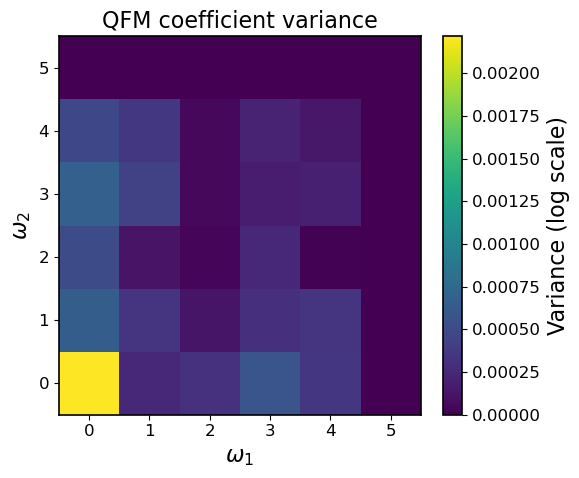

In [24]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(6,5))
# plt.imshow(var_QFM,
#            origin="lower",
#            aspect="auto",
#            norm=LogNorm(vmin=1e-6))
plt.imshow(var_QFM,
           origin="lower",
           aspect="auto")
plt.colorbar(label="Variance (log scale)")
plt.xlabel(r"$\omega_1$")
plt.ylabel(r"$\omega_2$")
plt.title("QFM coefficient variance")
plt.tight_layout()
plt.show()